# Лабораторна робота №1
## Варіант 1. Класифікація спам-повідомлень

### 1. Постановка задачі
Побудувати власний Transformer Encoder для бінарної класифікації: ham=0, spam=1. Використовуємо наданий `spam.csv` (короткі SMS за змістом), без pretrained моделей. Вимірюємо accuracy, precision, recall та F1 для позитивного класу spam.

Baseline перевіряє навчання однієї компактної моделі; tuning порівнює конфігурації за validation. Test відкриваємо тільки після вибору фінальної моделі. Навчальні комірки запускаються вручну засобами Jupyter.

### 2. Налаштування експерименту

Шляхи визначаємо один раз від кореня репозиторію. Гіперпараметри baseline та бюджет навчання зібрано нижче; `GRID_CONFIGS` імпортується зі спільного runner, тому таблиця конфігурацій відповідає фактичному grid.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in (cwd, *cwd.parents)
                  if (p / "labs/lab01_transformer/src").is_dir()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Відкрийте notebook із репозиторію або каталогу Lab 1")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
from functools import partial
import pandas as pd
import torch
from IPython.display import display
from labs.lab01_transformer.src.common.reproducibility import seed_everything, device_info
from labs.lab01_transformer.src.common.text import Vocabulary, tokenize, BOS
from labs.lab01_transformer.src.common.checkpoint import load_checkpoint
from labs.lab01_transformer.src.common.experiments import GRID_CONFIGS, run_grid, select_checkpoint
from labs.lab01_transformer.src.common.inspection import (
    summarize_dataset, summarize_splits, read_training_results, summarize_checkpoint,
)
from labs.lab01_transformer.src.common.visualization import (
    plot_dataset_overview, plot_positional_encoding, plot_history, plot_comparison,
    plot_confusion_matrix, plot_causal_mask,
)
from labs.lab01_transformer.src.classification.data import (
    inspect_data, clean_data, split_data, choose_max_length,
)
from labs.lab01_transformer.src.classification.data import create_loaders, class_weights
from labs.lab01_transformer.src.classification.model import SpamClassifier
from labs.lab01_transformer.src.classification.inspection import inspect_classifier_pipeline
from labs.lab01_transformer.src.classification.train import fit_classifier
from labs.lab01_transformer.src.classification.evaluate import evaluate_final_classifier

In [3]:
SEED = 42
BATCH_SIZE = 32
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 1e-3
VOCAB_CONFIG = dict(max_size=8000, min_frequency=2)
MAX_LENGTH_CAP = 96
MODEL_CONFIG = dict(d_model=64, nhead=2, num_layers=1,
                    dim_feedforward=256, dropout=.1)

In [4]:
LAB_ROOT = REPO_ROOT / "labs" / "lab01_transformer"
DATA_PATH = LAB_ROOT / "data" / "raw" / "spam.csv"
OUTPUT_DIR = LAB_ROOT / "outputs" / "classification" / "early_stopping"
BASELINE_DIR = OUTPUT_DIR / "baseline"
BASELINE_CHECKPOINT = BASELINE_DIR / "checkpoints" / "best.pt"
EXPERIMENTS_DIR = OUTPUT_DIR / "experiments"
FIGURES_DIR = OUTPUT_DIR / "figures"

Фіксуємо seed Python, NumPy та PyTorch. CUDA обирається автоматично, CPU залишається доступним; тотожність між різним обладнанням не гарантується. Компактний baseline розрахований на локальне навчання з 4 GB VRAM. Нові запуски використовують `early_stopping/`, не змішуючись зі старим протоколом; повторний запуск у цьому каталозі перезаписує відповідні артефакти.

In [5]:
seed_everything(SEED)
DEVICE = device_info()
display(pd.DataFrame(GRID_CONFIGS, columns=["d_model", "nhead"]))

PyTorch: 2.14.0+cu130; device: cuda
NVIDIA GeForce RTX 3050 Laptop GPU


,d_model,nhead
0,64,2
1,64,4
2,128,2
3,128,4


### 3. Завантаження та аналіз даних

Перевіряємо UTF-8, колонки `Category`/`Message`, пропуски, дублікати, класи та довжини. Очищення видаляє порожні тексти, повтори за токенізованим вмістом і суперечливі мітки. Оригінальний CSV не змінюється.

In [6]:
raw_data, raw_inspection = inspect_data(DATA_PATH)
data = clean_data(raw_data)
dataset_info = summarize_dataset(raw_inspection, data)
display(dataset_info)
display(data.head())

,Значення
raw.rows,5572.000000
raw.duplicate_texts,415.000000
raw.missing.Category,0.000000
raw.missing.Message,0.000000
raw.count.ham,4825.000000
raw.count.spam,747.000000
raw.percent.ham,86.593683
raw.percent.spam,13.406317
raw.tokens.count,5572.000000
raw.tokens.mean,20.458363


,Category,Message,key,label
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point , crazy . . available on...",0
1,ham,Ok lar... Joking wif u oni...,ok lar . . . joking wif u oni . . .,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,1
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor . . . u c already then ...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don ' t think he goes to usf , he lives ...",0


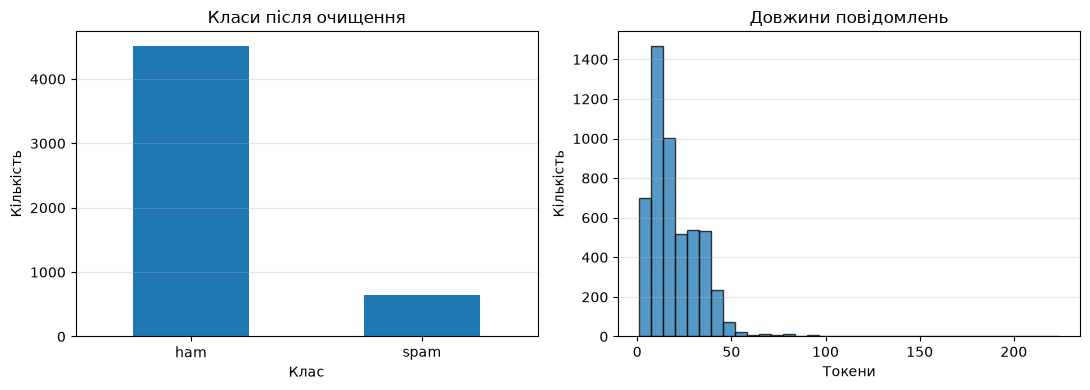

In [7]:
dataset_figure = plot_dataset_overview(data, FIGURES_DIR / "data_distribution.png")
display(dataset_figure)

**Інтерпретація.** Порівняйте кількість рядків до й після очищення та частки ham/spam. Для classification дисбаланс пояснює потребу у F1 і weighted loss; для generation довжини визначають обсяг вікон. Максимальну довжину обираємо нижче тільки за train, а не за цією загальною гістограмою.

### 4. Розбиття та словник

Використовуємо стратифіковане розбиття 70/15/15 із seed=42: більшість повідомлень потрібна для навчання, а окремі validation і test — для вибору моделі та незалежної підсумкової оцінки. Однакові токенізовані тексти видаляємо **до** розбиття; усі записи із суперечливими мітками виключаємо.

Regex виділяє слова та пунктуацію, приводячи літери до нижнього регістру. Словник будуємо **тільки на train**, залишаючи токени з частотою ≥2. PAD=0, UNK=1, BOS=2, EOS=3. Максимальна довжина визначається 95-м перцентилем train з обмеженням 96 для локального GPU; довгі класифікаційні входи обрізаються. Статистики validation/test не налаштовують preprocessing.

In [8]:
splits = split_data(data, seed=SEED)
vocabulary = Vocabulary.build(splits["train"].Message, **VOCAB_CONFIG)
max_len = choose_max_length(splits["train"].Message, cap=MAX_LENGTH_CAP)
split_summary, encoding_summary = summarize_splits(splits, vocabulary, max_len)
display(split_summary, encoding_summary)

,rows,ham,spam,spam_percent
split,,,,
train,3609,3160,449,12.441119
validation,773,677,96,12.419146
test,774,678,96,12.403101


vocabulary_size                 3202.000000
max_len                           42.000000
train_length_p95                  42.000000
train_fraction_above_max_len       0.045996
Name: Train preprocessing, dtype: float64

In [9]:
sample_text = splits["train"].Message.iloc[0]
display(pd.DataFrame({"token": tokenize(sample_text), "id": vocabulary.encode(sample_text)}).head(16))

,token,id
0,dear,148
1,where,134
2,you,6
3,.,4
4,call,30
5,me,18


**Інтерпретація.** `summarize_splits` перевіряє неперетин токенізованих текстів. Зіставте частки spam між split; перегляньте 95-й перцентиль train і частку текстів довших за max_len. Для classifier такі входи обрізаються, для generator — діляться на вікна. Таблиця token → id показує вихід tokenizer; словник validation/test не доповнюється.

### 5. DataLoader і балансування класів
Повідомлення доповнюються PAD праворуч до найдовшого входу в batch. `input_ids == PAD` створює булевий padding mask. Ваги `N / (2 × N_class)` обчислюються лише на train і передаються до CrossEntropyLoss. Oversampling не застосовується одночасно з вагами.

In [10]:
training_splits = {name: splits[name] for name in ("train", "validation")}
make_loaders = partial(create_loaders, training_splits, vocabulary, max_len, batch_size=BATCH_SIZE)
loaders = make_loaders(seed=SEED)
class_weights_tensor = class_weights(splits["train"].label)
display(pd.Series(class_weights_tensor.numpy(), index=["ham", "spam"], name="Вага класу"))

ham     0.571044
spam    4.018931
Name: Вага класу, dtype: float32

### 6. Transformer Encoder

`tokens → ids → embedding → PE → Transformer Encoder → masked mean pooling → Linear → logits`.

Query і Key визначають ваги уваги до Value. Для класифікації цілого повідомлення дозволено двонаправлений контекст. Padding mask виключає PAD із ключів attention, masked mean — із pooling. Нижче інспекція одного малого batch показує реальні проміжні форми та перевіряє відповідність звичайному forward; навчання використовує лише `model(input_ids)`.

In [11]:
model_config = dict(MODEL_CONFIG, vocab_size=len(vocabulary), max_len=max_len)
model = SpamClassifier(**model_config).to(DEVICE)
print(model)
input_ids, labels = next(iter(loaders["validation"]))
shape_summary = inspect_classifier_pipeline(model, input_ids[:2])
display(shape_summary)

SpamClassifier(
  (embedding): Embedding(3202, 64, padding_idx=0)
  (position): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)


,shape,dtype
stage,,
input_ids,"(2, 42)",torch.int64
padding_mask,"(2, 42)",torch.bool
embedding,"(2, 42, 64)",torch.float32
positional_encoding,"(2, 42, 64)",torch.float32
encoder_output,"(2, 42, 64)",torch.float32
pooled,"(2, 64)",torch.float32
logits,"(2, 2)",torch.float32


### 7. Позиційне кодування

Self-attention без позиційної інформації не визначає порядок токенів. До embedding додаємо фіксовані синусоїди:

$$PE(pos,2i)=\sin(pos/10000^{2i/d_{model}}),\quad PE(pos,2i+1)=\cos(pos/10000^{2i/d_{model}}).$$

На тепловій карті різні виміри мають різні частоти. Buffer переноситься разом із моделлю між CPU та CUDA; параметри PE не навчаються.

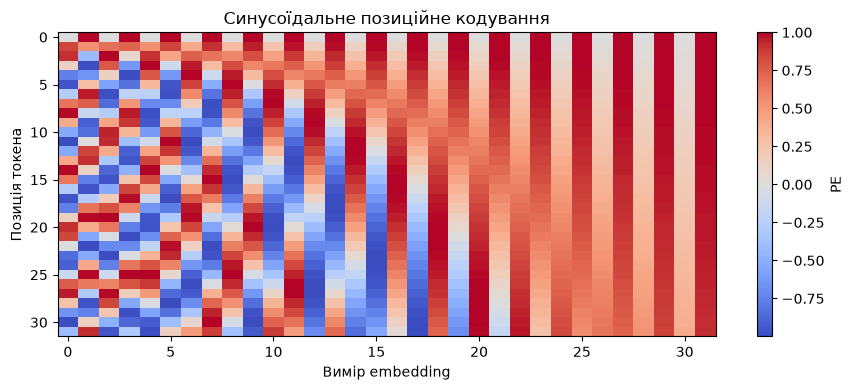

In [12]:
position_figure = plot_positional_encoding(model.position, FIGURES_DIR / "positional_encoding.png")
display(position_figure)

### 8. Baseline та early stopping

Baseline — одна компактна конфігурація для аналізу навчання, а не автоматично фінальна модель. AdamW мінімізує зважену cross-entropy. Для вибору checkpoint використовуємо **validation F1 позитивного класу spam**, який враховує precision та recall.

`MAX_EPOCHS=30` — верхня межа, а не обов'язкова тривалість. Після кожної епохи перевіряємо validation; якщо F1 не зростає протягом `PATIENCE=5` послідовних епох, навчання зупиняється. Строге зростання скидає лічильник, рівність не вважається покращенням. Зберігається checkpoint найкращої validation-епохи. Ця політика обмежує витрати часу, але не гарантує оптимального узагальнення.

> **Ручний запуск.** Ця комірка запускає навчання моделі та може виконуватися кілька хвилин. Запускайте її після підготовчих комірок. Test не бере участі в навчанні чи early stopping.

In [13]:
seed_everything(SEED)
model = SpamClassifier(**model_config)
loaders = make_loaders(seed=SEED)
baseline_result = fit_classifier(
    model, loaders, vocabulary, DEVICE, BASELINE_DIR, class_weights_tensor,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, learning_rate=LEARNING_RATE, seed=SEED,
)

{'epoch': 1, 'train_loss': 0.44359635976372963, 'validation_loss': 0.33585641913935904, 'validation_accuracy': 0.8771021992238034, 'validation_precision': 0.5032258064516129, 'validation_recall': 0.8125, 'validation_f1': 0.6215139442231076}
{'epoch': 2, 'train_loss': 0.19770138762551487, 'validation_loss': 0.3247342814453114, 'validation_accuracy': 0.9184993531694696, 'validation_precision': 0.627906976744186, 'validation_recall': 0.84375, 'validation_f1': 0.72}
{'epoch': 3, 'train_loss': 0.12929775584399877, 'validation_loss': 0.3457337911617534, 'validation_accuracy': 0.944372574385511, 'validation_precision': 0.7431192660550459, 'validation_recall': 0.84375, 'validation_f1': 0.7902439024390244}
{'epoch': 4, 'train_loss': 0.08831874445473673, 'validation_loss': 0.40681538882964097, 'validation_accuracy': 0.9340232858990944, 'validation_precision': 0.6956521739130435, 'validation_recall': 0.8333333333333334, 'validation_f1': 0.7582938388625592}
{'epoch': 5, 'train_loss': 0.07324095039

#### Збережені результати baseline

Читаємо історію й summary з диска: best epoch може не збігатися з останньою епохою. Після перезапуску kernel повторне навчання не потрібне, якщо ці артефакти вже існують. Криві містять лише фактично виконані епохи.

,Значення
best_epoch,16
epochs_trained,21
stopped_early,True
stop_reason,patience
seconds,25.05363
parameters,255042
best_validation_metric.loss,0.796229
best_validation_metric.accuracy,0.972833
best_validation_metric.precision,0.921348
best_validation_metric.recall,0.854167


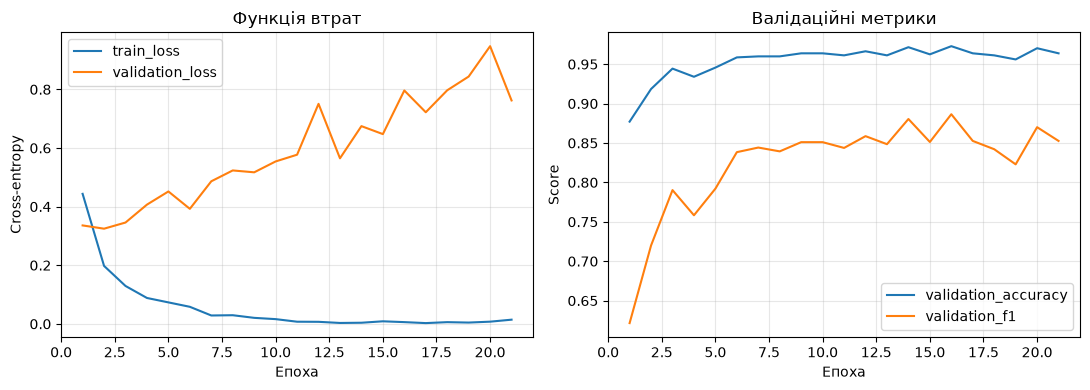

In [14]:
baseline_history, training_summary = read_training_results(BASELINE_DIR)
display(training_summary)
history_figure = plot_history(baseline_history, "classification", FIGURES_DIR / "history.png")
display(history_figure)

**Інтерпретація.** Вкажіть best epoch і причину завершення. Зіставте train/validation loss та validation-метрики; розходження кривих може свідчити про перенавчання. Числові висновки формулюються за фактичними результатами.

### 9. Підбір d_model і nhead

Порівнюємо 64/2, 64/4, 128/2 та 128/4. `d_model` задає розмір представлення токена, `nhead` — кількість attention heads; подільність перевіряє конструктор. Інші параметри, split, seed, порядок batch та early-stopping policy однакові. Кількість фактично виконаних епох може відрізнятися: кожна модель зупиняється за власною validation-кривою. Вибір — за validation F1 (максимум).

Якщо поки досліджуєте лише baseline, пропустіть комірки grid і comparison. Остаточне виконання лабораторної включає порівняння обов'язкових гіперпараметрів.

> **Ручний запуск.** Буде навчено чотири моделі, кожну максимум `MAX_EPOCHS` епох із `PATIENCE` непокращень. Цей етап довший за baseline і не оцінює test.

In [15]:
grid_results = run_grid(
    SpamClassifier, model_config, make_loaders, vocabulary, DEVICE,
    EXPERIMENTS_DIR, "classification", weights=class_weights_tensor,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, learning_rate=LEARNING_RATE, seed=SEED,
)
display(grid_results)

{'epoch': 1, 'train_loss': 0.44359635976372963, 'validation_loss': 0.33585641913935904, 'validation_accuracy': 0.8771021992238034, 'validation_precision': 0.5032258064516129, 'validation_recall': 0.8125, 'validation_f1': 0.6215139442231076}
{'epoch': 2, 'train_loss': 0.19770138762551487, 'validation_loss': 0.3247342814453114, 'validation_accuracy': 0.9184993531694696, 'validation_precision': 0.627906976744186, 'validation_recall': 0.84375, 'validation_f1': 0.72}
{'epoch': 3, 'train_loss': 0.12929775584399877, 'validation_loss': 0.3457337911617534, 'validation_accuracy': 0.944372574385511, 'validation_precision': 0.7431192660550459, 'validation_recall': 0.84375, 'validation_f1': 0.7902439024390244}
{'epoch': 4, 'train_loss': 0.08831874445473673, 'validation_loss': 0.40681538882964097, 'validation_accuracy': 0.9340232858990944, 'validation_precision': 0.6956521739130435, 'validation_recall': 0.8333333333333334, 'validation_f1': 0.7582938388625592}
{'epoch': 5, 'train_loss': 0.07324095039

,d_model,nhead,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,best_epoch,epochs_trained,stopped_early,parameters,seconds,checkpoint
0,64,2,0.796229,0.972833,0.921348,0.854167,0.886486,16,21,True,255042,24.996930,d64_h2\checkpoints\best.pt
1,64,4,0.358018,0.968952,0.867347,0.885417,0.876289,5,10,True,255042,11.120437,d64_h4\checkpoints\best.pt
2,128,2,0.513244,0.971539,0.902174,0.864583,0.882979,15,20,True,542594,22.791842,d128_h2\checkpoints\best.pt
3,128,4,0.443186,0.976714,0.943182,0.864583,0.902174,12,17,True,542594,19.580813,d128_h4\checkpoints\best.pt


#### Порівняння validation-результатів

Таблицю можна відкрити й після перезапуску kernel. Порівнюйте найкращі validation-метрики разом із best_epoch, фактичною кількістю епох, кількістю параметрів та часом. Якщо grid поки пропущено, пропустіть і цей графік.

,d_model,nhead,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,best_epoch,epochs_trained,stopped_early,parameters,seconds,checkpoint
0,64,2,0.796229,0.972833,0.921348,0.854167,0.886486,16,21,True,255042,24.996930,d64_h2\checkpoints\best.pt
1,64,4,0.358018,0.968952,0.867347,0.885417,0.876289,5,10,True,255042,11.120437,d64_h4\checkpoints\best.pt
2,128,2,0.513244,0.971539,0.902174,0.864583,0.882979,15,20,True,542594,22.791842,d128_h2\checkpoints\best.pt
3,128,4,0.443186,0.976714,0.943182,0.864583,0.902174,12,17,True,542594,19.580813,d128_h4\checkpoints\best.pt


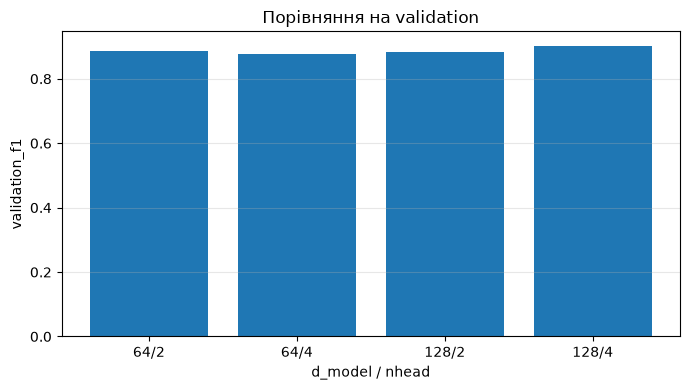

In [16]:
grid_results = pd.read_csv(EXPERIMENTS_DIR / "comparison.csv")
display(grid_results)
comparison_figure = plot_comparison(grid_results, "validation_f1",
                                    FIGURES_DIR / "comparison.png")
display(comparison_figure)

### 10. Вибір і відновлення моделі

Порівнюємо baseline і виконані grid-експерименти за максимальним validation F1. Baseline не є автоматичним переможцем. Якщо grid пропущено, залишається baseline. Завантажуємо збережені ваги, словник і конфігурацію найкращої validation-епохи — вони можуть відрізнятися від стану моделі в останній епосі.

Ця комірка потребує збереженого baseline або grid у поточному `OUTPUT_DIR`. Після перезапуску kernel достатньо повторити підготовку даних і цю комірку; повторне навчання не потрібне.

In [17]:
selected_checkpoint = select_checkpoint(BASELINE_CHECKPOINT, EXPERIMENTS_DIR, "classification")
selected_model, saved_vocabulary, checkpoint_metadata = load_checkpoint(selected_checkpoint, DEVICE)
display(summarize_checkpoint(checkpoint_metadata))
print(selected_checkpoint)

,Обрана модель
model.vocab_size,3202.000000
model.max_len,42.000000
model.d_model,128.000000
model.nhead,4.000000
model.num_layers,1.000000
model.dim_feedforward,256.000000
model.dropout,0.100000
best_epoch,12.000000
validation.loss,0.443186
validation.accuracy,0.976714


C:\Users\Eclipse\PycharmProjects\neural-network-technologies-and-systems\labs\lab01_transformer\outputs\classification\early_stopping\experiments\d128_h4\checkpoints\best.pt


### 11. Фінальне оцінювання на test-вибірці

Матриця помилок відокремлює false positives від пропущеного spam. Confidence — softmax-оцінка, не гарантовано калібрована ймовірність. Вхід кодується словником відновленого checkpoint.

> **Ручний запуск. Важливо:** виконайте цю комірку лише один раз після завершення підбору гіперпараметрів і вибору моделі за validation. Test не використовується для налаштування моделі. Спочатку виконайте комірку відновлення checkpoint.

In [18]:
saved_weights = torch.tensor(checkpoint_metadata["training_config"]["class_weights"])
test_metrics, predictions = evaluate_final_classifier(
    selected_model, saved_vocabulary, splits["test"], DEVICE, saved_weights, OUTPUT_DIR,
    batch_size=BATCH_SIZE, seed=SEED,
)
display(pd.Series(test_metrics, name="Test"))

loss         0.276265
accuracy     0.963824
precision    0.833333
recall       0.885417
f1           0.858586
Name: Test, dtype: float64

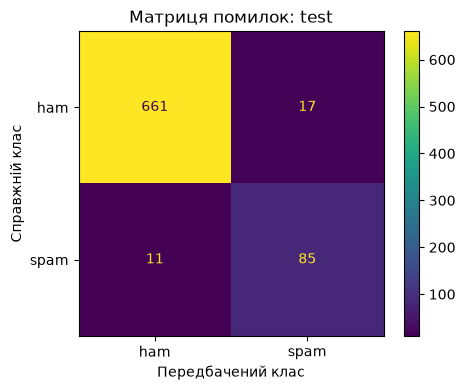

,text,prediction,confidence,spam_probability,actual
0,Dear we are going to our rubber place,0,0.999999,0.000001,0
1,Don't make life too stressfull.. Always find t...,0,0.646166,0.353834,0
2,She just broke down a list of reasons why nobo...,0,0.999977,0.000023,0
3,YOUR CHANCE TO BE ON A REALITY FANTASY SHOW ca...,1,0.999850,0.999850,1
27,Gr8 new service - live sex video chat on your ...,1,1.000000,1.000000,1
34,Collect your VALENTINE'S weekend to PARIS inc ...,1,0.999998,0.999998,1


In [19]:
confusion_figure = plot_confusion_matrix(predictions, FIGURES_DIR / "confusion_matrix.png")
display(confusion_figure)
display(predictions.groupby("actual", group_keys=False).head(3))

**Інтерпретація.** Порівняйте false positives та пропущений spam. Наведіть характерні помилки й перевірте, чи могли обрізання або UNK вплинути на результат. Test не використовується для повторного tuning.

### 12. Висновки

На очищеному spam.csv навчено Transformer Encoder для ham/spam; позитивний клас — spam. Словник і ваги класів побудовано лише за train. Baseline 64/2 з одним шаром має 255 042 параметри: 21 епоха, найкраща — 16, зупинка після п'яти епох без зростання validation F1. F1 зріс із 0,621514 до 0,886486. Водночас train loss знизився з 0,443596 до 0,014274, а validation loss після мінімуму 0,324734 на епосі 2 зріс до 0,796229 на найкращій за F1 епосі. Це ознаки перенавчання за cross-entropy й надмірної впевненості в помилках; мінімум loss не був критерієм вибору.

За максимальним validation F1 серед baseline і чотирьох grid-конфігурацій обрано **d_model=128, nhead=4, num_layers=1, dim_feedforward=256, dropout=0.1**: 542 594 параметри, 17 епох, best_epoch=12, stop_reason=patience. На validation: loss=0,443186, accuracy=0,976714, precision=0,943182, recall=0,864583, **F1=0,902174**. Збережений час цього запуску — 19,58 с; це локальне вимірювання, не універсальний benchmark. Checkpoint відновлює епоху 12, а не останню 17.

Фінальний test обраної моделі: **accuracy=0,963824, precision=0,833333, recall=0,885417, F1=0,858586**, weighted loss=0,276265. Матриця помилок (рядки — actual ham/spam, стовпці — predicted ham/spam): `[[661, 17], [11, 85]]`. Із 96 spam виявлено 85 та пропущено 11; 17 із 678 ham помилково позначено spam. Отже, recall 88,54% супроводжується precision 83,33%: приблизно кожне шосте спрацювання є хибним. Прийнятність такого співвідношення залежить від ціни блокування легітимних повідомлень і пропуску spam; сама accuracy не описує його.

Test F1 нижчий за validation на 0,043588; precision зменшується, recall дещо зростає. Результат зберігає здатність виявляти spam на відкладених даних, але розрив loss і F1 не дозволяє стверджувати відсутність перенавчання. Частка ham велика, тому F1/precision/recall та кількості помилок інформативніші за accuracy окремо. Одного seed недостатньо для оцінки статистичної стійкості перемоги 128/4.

Джерела чисел: `outputs/classification/early_stopping/` — baseline/grid history та summary, `experiments/comparison.csv`, checkpoint metadata, `metrics/test.json` і `metrics/predictions.csv`. Збережений порядок виконання: grid → вибір checkpoint → final test; test не входить у критерій вибору. Поточні результати не змішано з історичним п'ятиепоховим протоколом.
